# Student Focus Monitor — Facial State Classifier\n\nTrains a 4-class model that classifies a student's webcam frame into one of the states used by the Student Focus Monitor's gamification engine:\n\n- **Focused** — studying well\n- **Fatigue** — tired (blink rate up, yawning)\n- **Anxiety** — worried (eyes darting, brow furrowed, fidgeting)\n- **Boredom** — bored (gaze wandering, head turning, slumped posture)\n\n**Data sources**\n- `Focused` / `Fatigue` / `Anxiety` — the `face_detection` dataset (pre-cropped 224x224 faces, already split `train`/`valid`/`test`).\n- `Boredom` — the `DAiSEE` dataset only. DAiSEE has no folder of boredom images; instead it labels 10-second video clips with a crowd-annotated Boredom score (0-3). We pull a frame from every clip scored >= 2 and crop it to the face the same way as the other three classes, so the model can't just learn \"wide background = bored\" instead of an actual facial cue.\n\n**Modeling approach**\n1. Build the unified 4-class image dataset (`train`/`val`/`test`).\n2. Extract interpretable per-frame features (eye aspect ratio, mouth aspect ratio, brow position, gaze offset, head pose, 52 ARKit blendshapes) with MediaPipe's Face Landmarker — the same features the real-time system computes once a second.\n3. Train three classical classifiers on those features — Random Forest, XGBoost, SVM — and compare them.\n4. Train a MobileNetV2 CNN (two-stage transfer learning) directly on the cropped face images.\n5. Evaluate all four models on the same held-out test split and keep the most accurate one.

In [1]:
%matplotlib inline
import json
import random
import time
import warnings
import zlib
from pathlib import Path

import cv2
import joblib
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from scipy.spatial.transform import Rotation
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("TensorFlow:", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0 | GPUs: []


In [2]:
NOTEBOOK_DIR = Path.cwd()
BACKEND_ROOT = NOTEBOOK_DIR.parents[1]
assert (BACKEND_ROOT / "datasets" / "focusmonitor").exists(), f"Unexpected working directory: {NOTEBOOK_DIR}"

SOURCE_ROOT = BACKEND_ROOT / "datasets" / "focusmonitor"
FACE_DETECTION_ROOT = SOURCE_ROOT / "face_detection"
DAISEE_ROOT = SOURCE_ROOT / "DAiSEE"
UNIFIED_ROOT = BACKEND_ROOT / "datasets" / "focus_dataset_unified"
MODEL_DIR = BACKEND_ROOT / "trained-models" / "focus"
LANDMARKER_MODEL_PATH = NOTEBOOK_DIR / "models" / "face_landmarker.task"
FEATURES_CACHE_PATH = NOTEBOOK_DIR / "cache" / "landmark_features.csv"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

CLASSES = ["Focused", "Fatigue", "Anxiety", "Boredom"]
SPLITS = ["train", "val", "test"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

print("Backend root:      ", BACKEND_ROOT)
print("Unified dataset ->  ", UNIFIED_ROOT)
print("Trained models ->   ", MODEL_DIR)

Backend root:       c:\Users\CNN COMPUTERS\OneDrive\Documents\Research\Smart-Uni-Guide\backend
Unified dataset ->   c:\Users\CNN COMPUTERS\OneDrive\Documents\Research\Smart-Uni-Guide\backend\datasets\focus_dataset_unified
Trained models ->    c:\Users\CNN COMPUTERS\OneDrive\Documents\Research\Smart-Uni-Guide\backend\trained-models\focus


## 1. Build the unified dataset

Copies `Focused`/`Fatigue`/`Anxiety` from `face_detection` as-is, then adds a `Boredom` class (plus supplements for `Focused` and `Anxiety`) sampled from DAiSEE. Re-running this notebook top-to-bottom always rebuilds `focus_dataset_unified/` from scratch, so the result stays reproducible.

> **Revision note (round 2).** The first version of this pipeline made Boredom the *only* class ever sourced from DAiSEE, and it turned out DAiSEE's frames have a distinctive visual signature (video compression, resolution, sensor noise) that differs from `face_detection`'s clean, curated images. A model trained on that split learns "this looks like a DAiSEE frame" as a shortcut for "Boredom" -- confirmed by testing on DAiSEE clips explicitly labeled *not* bored, which still predicted Boredom with near-100% confidence.
>
> Round 1 added `domain_jitter` (randomized compression/blur/noise on every image) and a DAiSEE-sourced Focused supplement (Engagement==3 & Boredom==0). That cut the false-positive rate on held-out not-bored DAiSEE clips from 100% to 48% -- real progress, but the section 7 breakdown showed *zero* of those clips were ever predicted Fatigue, and very few Anxiety: with only Focused and Boredom having any DAiSEE-domain (real-video) representation, the model still partly falls back to "is this real video" to decide between those two whenever the DAiSEE-domain signal dominates.
>
> Round 2 adds a third DAiSEE-sourced supplement: **Anxiety**, proxied by DAiSEE's own Frustration score (Frustration >= 2 -- brow tension/frustration is a reasonable proxy for anxious tension, the same logic the project's earlier FER-based pipeline used for angry/fear). Fatigue has no comparable DAiSEE label to proxy from (DAiSEE doesn't capture drowsiness/yawning), so it remains `face_detection`-only; `domain_jitter`'s ranges are widened instead to close as much of that residual gap as augmentation alone can.

### 1.1 Focused / Fatigue / Anxiety -- from `face_detection`

These images are already cropped tightly to the face and pre-split into `train`/`valid`/`test` (verified below: MediaPipe's landmark bounding box already fills ~100% of the frame). We copy them into the unified layout (renaming `valid` -> `val`), applying `domain_jitter` to each one.

In [3]:
import shutil

FACE_DETECTION_SPLIT_MAP = {"train": "train", "valid": "val", "test": "test"}
FACE_DETECTION_CLASSES = ["Focused", "Fatigue", "Anxiety"]


def list_images(folder: Path):
    if not folder.exists():
        return []
    return sorted(p for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXTS)


def domain_jitter(image_bgr, seed):
    """Randomized resolution-loss + JPEG recompression + noise, applied to
    every image regardless of source. Prevents the model from using each
    source dataset's distinct compression/quality signature as a shortcut
    for its label -- see the revision note above. Ranges widened in round 2
    (0.5->0.35 min scale, 35->25 min JPEG quality, wider noise) since round 1's
    milder jitter alone still left a detectable domain gap for classes with no
    DAiSEE-domain representation (see section 7)."""
    rng = random.Random(seed)
    img = image_bgr
    h, w = img.shape[:2]

    scale = rng.uniform(0.35, 1.0)
    small = cv2.resize(img, (max(1, int(w * scale)), max(1, int(h * scale))), interpolation=cv2.INTER_AREA)
    img = cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)

    if rng.random() < 0.6:
        k = rng.choice([3, 5, 5])
        img = cv2.GaussianBlur(img, (k, k), 0)

    quality = rng.randint(25, 90)
    ok, enc = cv2.imencode(".jpg", img, [cv2.IMWRITE_JPEG_QUALITY, quality])
    if ok:
        img = cv2.imdecode(enc, cv2.IMREAD_COLOR)

    noise_sigma = rng.uniform(0, 8)
    if noise_sigma > 0:
        noise = np.random.default_rng(seed).normal(0, noise_sigma, img.shape).astype(np.float32)
        img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    return img


def build_face_detection_classes():
    if UNIFIED_ROOT.exists():
        shutil.rmtree(UNIFIED_ROOT)

    counts = {}
    for src_split, dst_split in FACE_DETECTION_SPLIT_MAP.items():
        for cls in FACE_DETECTION_CLASSES:
            files = list_images(FACE_DETECTION_ROOT / src_split / cls)
            dst_dir = UNIFIED_ROOT / dst_split / cls
            dst_dir.mkdir(parents=True, exist_ok=True)
            for f in files:
                img = domain_jitter(cv2.imread(str(f)), seed=zlib.crc32(f.name.encode()))
                cv2.imwrite(str(dst_dir / f.name), img)
            counts[(dst_split, cls)] = len(files)
    return counts


face_counts = build_face_detection_classes()
for (split, cls), n in sorted(face_counts.items()):
    print(f"{split:>5} / {cls:<8}: {n}")

 test / Anxiety : 67
 test / Fatigue : 67
 test / Focused : 61
train / Anxiety : 493
train / Fatigue : 437
train / Focused : 436
  val / Anxiety : 137
  val / Fatigue : 123
  val / Focused : 130


### 1.2 Boredom, Focused, and Anxiety supplements -- from DAiSEE

DAiSEE labels each clip with Boredom, Engagement, Confusion and Frustration scores (0-3 each, crowd-annotated). We pull three disjoint sets of clips:
- **Boredom** -- score >= 2, i.e. clearly bored.
- **Focused supplement** -- Engagement == 3 *and* Boredom == 0, i.e. fully engaged and not bored at all.
- **Anxiety supplement** -- Frustration >= 2, i.e. visibly frustrated/tense (used as a proxy the same way the project's earlier FER-based pipeline treated angry/fear as an Anxiety proxy -- DAiSEE has no direct anxiety label).

All three are disjoint by construction (Boredom>=2 rules out Boredom==0; Frustration is independent of the other two masks, and in practice barely overlaps them). Adding Focused and Anxiety supplements means three of the four classes have real DAiSEE-domain (webcam video) representation, not just Boredom -- this is what section 7's regression check is checking has actually closed the gap.

For every selected clip we take the middle frame, detect the face with MediaPipe and crop it with a small 5% margin -- matched to how tightly `face_detection`'s own images are cropped -- then apply the same `domain_jitter` used for the other classes.

The number of frames pulled per split (for each of the three sets) is capped at the *average* image count of `face_detection`'s three classes in that split, so no DAiSEE-sourced set dominates. DAiSEE's own Train/Validation/Test folders are split by person, and we route them 1:1 onto train/val/test so a person's face never crosses a split boundary.

In [4]:
BOREDOM_THRESHOLD = 2
FOCUSED_ENGAGEMENT_THRESHOLD = 3
ANXIETY_FRUSTRATION_THRESHOLD = 2
CROP_MARGIN = 0.05
CROP_SIZE = 224

DAISEE_SPLIT_MAP = {
    "Train": ("TrainLabels.csv", "train"),
    "Validation": ("ValidationLabels.csv", "val"),
    "Test": ("TestLabels.csv", "test"),
}

target_daisee_counts = {
    dst_split: round(np.mean([face_counts[(dst_split, cls)] for cls in FACE_DETECTION_CLASSES]))
    for dst_split in set(FACE_DETECTION_SPLIT_MAP.values())
}
print("Target DAiSEE-sourced frame count per split (used for Boredom, the Focused supplement, and the Anxiety supplement):", target_daisee_counts)


def _load_daisee_labels(labels_csv: Path):
    df = pd.read_csv(labels_csv)
    df.columns = df.columns.str.strip()
    df["ClipID"] = df["ClipID"].astype(str).str.strip()
    return df


def load_bored_clip_ids(labels_csv: Path):
    df = _load_daisee_labels(labels_csv)
    return sorted(df[df["Boredom"] >= BOREDOM_THRESHOLD]["ClipID"].tolist())


def load_focused_proxy_clip_ids(labels_csv: Path):
    df = _load_daisee_labels(labels_csv)
    mask = (df["Engagement"] >= FOCUSED_ENGAGEMENT_THRESHOLD) & (df["Boredom"] == 0)
    return sorted(df[mask]["ClipID"].tolist())


def load_anxiety_proxy_clip_ids(labels_csv: Path):
    df = _load_daisee_labels(labels_csv)
    mask = df["Frustration"] >= ANXIETY_FRUSTRATION_THRESHOLD
    return sorted(df[mask]["ClipID"].tolist())


def evenly_spaced_sample(items, cap):
    n = len(items)
    if n <= cap:
        return list(items)
    step = n / cap
    idx = sorted({int(i * step) for i in range(cap)})
    return [items[i] for i in idx]


def index_clip_files(split_dir: Path):
    return {p.name: p for p in split_dir.rglob("*.avi")}


def crop_face(image_bgr, landmarker, margin=CROP_MARGIN, out_size=CROP_SIZE):
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = landmarker.detect(mp_image)
    if not result.face_landmarks:
        return None

    h, w = image_bgr.shape[:2]
    xs = [p.x * w for p in result.face_landmarks[0]]
    ys = [p.y * h for p in result.face_landmarks[0]]
    x0, x1, y0, y1 = min(xs), max(xs), min(ys), max(ys)
    bw, bh = x1 - x0, y1 - y0
    x0, x1 = x0 - bw * margin, x1 + bw * margin
    y0, y1 = y0 - bh * margin, y1 + bh * margin
    x0, y0 = max(int(x0), 0), max(int(y0), 0)
    x1, y1 = min(int(x1), w), min(int(y1), h)
    if x1 <= x0 or y1 <= y0:
        return None

    crop = image_bgr[y0:y1, x0:x1]
    return cv2.resize(crop, (out_size, out_size), interpolation=cv2.INTER_AREA)

Target DAiSEE-sourced frame count per split (used for Boredom, the Focused supplement, and the Anxiety supplement): {'val': 130, 'train': 455, 'test': 65}


In [5]:
def build_daisee_class(landmarker, clip_loader_fn, dest_class: str, label: str):
    """Shared extraction routine for any DAiSEE-sourced class: loads the
    qualifying clip ids per split (via `clip_loader_fn`), samples up to
    `target_daisee_counts`, pulls the middle frame of each clip, crops the
    face, jitters it, and saves into UNIFIED_ROOT/<split>/<dest_class>.
    Used for Boredom, the Focused supplement, and the Anxiety supplement."""
    ids_by_split = {
        daisee_split: clip_loader_fn(DAISEE_ROOT / "Labels" / labels_file)
        for daisee_split, (labels_file, _) in DAISEE_SPLIT_MAP.items()
    }

    counts, skipped_no_face, skipped_no_video = {}, 0, 0
    for daisee_split, (labels_file, unified_split) in DAISEE_SPLIT_MAP.items():
        clip_ids = ids_by_split[daisee_split]
        target = target_daisee_counts[unified_split]
        selected = evenly_spaced_sample(clip_ids, target)
        clip_index = index_clip_files(DAISEE_ROOT / "DataSet" / daisee_split)

        dst_dir = UNIFIED_ROOT / unified_split / dest_class
        dst_dir.mkdir(parents=True, exist_ok=True)

        n_saved = 0
        for clip_id in selected:
            video_path = clip_index.get(clip_id)
            if video_path is None:
                skipped_no_video += 1
                continue

            cap = cv2.VideoCapture(str(video_path))
            frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_count // 2)
            ok, frame = cap.read()
            cap.release()
            if not ok:
                skipped_no_video += 1
                continue

            face = crop_face(frame, landmarker)
            if face is None:
                skipped_no_face += 1
                continue

            face = domain_jitter(face, seed=zlib.crc32(clip_id.encode()))
            out_path = dst_dir / f"DAiSEE_{Path(clip_id).stem}.jpg"
            cv2.imwrite(str(out_path), face)
            n_saved += 1

        counts[unified_split] = n_saved
        print(
            f"[{label}] {daisee_split:>10}: {len(clip_ids)} qualifying clips, "
            f"{len(selected)} sampled (target {target}), {n_saved} saved -> {unified_split}/{dest_class}"
        )

    print(f"[{label}] Skipped: {skipped_no_video} clip/video read failures, {skipped_no_face} with no face detected\n")
    return counts


_daisee_landmarker_options = vision.FaceLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path=str(LANDMARKER_MODEL_PATH)),
    num_faces=1,
    running_mode=vision.RunningMode.IMAGE,
)
_daisee_landmarker = vision.FaceLandmarker.create_from_options(_daisee_landmarker_options)

boredom_counts = build_daisee_class(_daisee_landmarker, load_bored_clip_ids, "Boredom", "Boredom")
focused_supplement_counts = build_daisee_class(_daisee_landmarker, load_focused_proxy_clip_ids, "Focused", "Focused-supplement")
anxiety_supplement_counts = build_daisee_class(_daisee_landmarker, load_anxiety_proxy_clip_ids, "Anxiety", "Anxiety-supplement")

[Boredom]      Train: 1229 qualifying clips, 455 sampled (target 455), 439 saved -> train/Boredom


[Boredom] Validation: 607 qualifying clips, 130 sampled (target 130), 130 saved -> val/Boredom


[Boredom]       Test: 377 qualifying clips, 65 sampled (target 65), 64 saved -> test/Boredom
[Boredom] Skipped: 16 clip/video read failures, 1 with no face detected



[Focused-supplement]      Train: 1594 qualifying clips, 455 sampled (target 455), 396 saved -> train/Focused


[Focused-supplement] Validation: 247 qualifying clips, 130 sampled (target 130), 130 saved -> val/Focused


[Focused-supplement]       Test: 508 qualifying clips, 65 sampled (target 65), 57 saved -> test/Focused
[Focused-supplement] Skipped: 67 clip/video read failures, 0 with no face detected



[Anxiety-supplement]      Train: 234 qualifying clips, 234 sampled (target 455), 225 saved -> train/Anxiety


[Anxiety-supplement] Validation: 100 qualifying clips, 100 sampled (target 130), 100 saved -> val/Anxiety


[Anxiety-supplement]       Test: 80 qualifying clips, 65 sampled (target 65), 64 saved -> test/Anxiety
[Anxiety-supplement] Skipped: 10 clip/video read failures, 0 with no face detected



### 1.3 Class balance

,train,val,test,total
Focused,832,260,118,1210
Fatigue,437,123,67,627
Anxiety,718,237,131,1086
Boredom,439,130,64,633


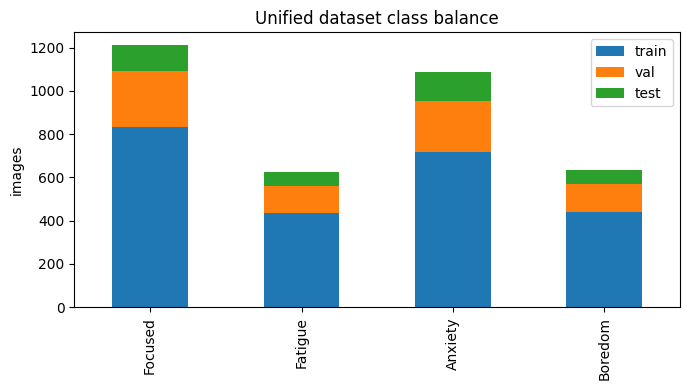

In [6]:
def count_images(folder: Path):
    return len(list_images(folder)) if folder.exists() else 0


balance = pd.DataFrame(
    {split: [count_images(UNIFIED_ROOT / split / cls) for cls in CLASSES] for split in SPLITS},
    index=CLASSES,
)
balance["total"] = balance[SPLITS].sum(axis=1)
display(balance)

balance[SPLITS].plot(kind="bar", stacked=True, figsize=(7, 4), title="Unified dataset class balance")
plt.ylabel("images")
plt.tight_layout()
plt.savefig(MODEL_DIR / "class_balance.png")
plt.show()

## 2. Feature engineering (MediaPipe Face Landmarker)\n\nFor every image in the unified dataset, run MediaPipe's Face Landmarker (478 landmarks + 52 blendshapes + a head-pose transformation matrix) and derive:\n\n- **Eye tracking** — eye aspect ratio per eye (blink proxy) and iris offset within the eye socket per eye (gaze proxy).\n- **Face tracking** — mouth aspect ratio (yawn proxy), brow-to-eye distance per side (furrow/raise proxy), and all 52 ARKit blendshape scores (covers facial tension generally — jaw, cheeks, lip press, etc.).\n- **Head pose** — pitch/yaw/roll decomposed from the landmarker's facial transformation matrix.\n\nImages where no face is detected are dropped from this tabular feature set (they're still used later for the CNN, which learns directly from pixels). Results are cached to `cache/landmark_features.csv` — delete that file to force a recompute after changing the dataset.

In [7]:
# Landmark index sets (MediaPipe FaceMesh topology, 478 points incl. iris)
EYE_LEFT = [33, 160, 158, 133, 153, 144]     # corner, top1, top2, corner, bottom1, bottom2
EYE_RIGHT = [263, 387, 385, 362, 380, 373]
MOUTH_CORNERS = (61, 291)
MOUTH_VERTICAL = (13, 14)
BROW_LEFT, EYE_TOP_LEFT = 105, 159
BROW_RIGHT, EYE_TOP_RIGHT = 334, 386
IRIS_LEFT, IRIS_RIGHT = 468, 473


def _dist(a, b):
    return float(np.hypot(a.x - b.x, a.y - b.y))


def _ear(lm, idx):
    p1, p2, p3, p4, p5, p6 = (lm[i] for i in idx)
    return (_dist(p2, p6) + _dist(p3, p5)) / (2 * _dist(p1, p4) + 1e-6)


def _mar(lm):
    top, bottom = lm[MOUTH_VERTICAL[0]], lm[MOUTH_VERTICAL[1]]
    left, right = lm[MOUTH_CORNERS[0]], lm[MOUTH_CORNERS[1]]
    return _dist(top, bottom) / (_dist(left, right) + 1e-6)


def _iris_offset(lm, iris_idx, eye_idx):
    iris = lm[iris_idx]
    corner1, corner2 = lm[eye_idx[0]], lm[eye_idx[3]]
    top, bottom = lm[eye_idx[1]], lm[eye_idx[4]]
    eye_w = _dist(corner1, corner2) + 1e-6
    eye_h = _dist(top, bottom) + 1e-6
    cx, cy = (corner1.x + corner2.x) / 2, (top.y + bottom.y) / 2
    return (iris.x - cx) / eye_w, (iris.y - cy) / eye_h


def _head_pose(matrix):
    rotation = np.array(matrix)[:3, :3]
    return Rotation.from_matrix(rotation).as_euler("xyz", degrees=True)


def extract_features(landmarker, image_bgr):
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = landmarker.detect(mp_image)
    if not result.face_landmarks:
        return None
    lm = result.face_landmarks[0]

    ear_l, ear_r = _ear(lm, EYE_LEFT), _ear(lm, EYE_RIGHT)
    gaze_lx, gaze_ly = _iris_offset(lm, IRIS_LEFT, EYE_LEFT)
    gaze_rx, gaze_ry = _iris_offset(lm, IRIS_RIGHT, EYE_RIGHT)

    features = {
        "ear_left": ear_l,
        "ear_right": ear_r,
        "ear_avg": (ear_l + ear_r) / 2,
        "mar": _mar(lm),
        "brow_eye_dist_left": lm[EYE_TOP_LEFT].y - lm[BROW_LEFT].y,
        "brow_eye_dist_right": lm[EYE_TOP_RIGHT].y - lm[BROW_RIGHT].y,
        "gaze_x_left": gaze_lx,
        "gaze_y_left": gaze_ly,
        "gaze_x_right": gaze_rx,
        "gaze_y_right": gaze_ry,
    }

    if result.facial_transformation_matrixes:
        pitch, yaw, roll = _head_pose(result.facial_transformation_matrixes[0])
    else:
        pitch, yaw, roll = 0.0, 0.0, 0.0
    features.update({"head_pitch": pitch, "head_yaw": yaw, "head_roll": roll})

    if result.face_blendshapes:
        for bs in result.face_blendshapes[0]:
            features[f"bs_{bs.category_name}"] = bs.score

    return features

In [8]:
def build_feature_table():
    base_options = mp_python.BaseOptions(model_asset_path=str(LANDMARKER_MODEL_PATH))
    options = vision.FaceLandmarkerOptions(
        base_options=base_options,
        output_face_blendshapes=True,
        output_facial_transformation_matrixes=True,
        num_faces=1,
        running_mode=vision.RunningMode.IMAGE,
    )
    landmarker = vision.FaceLandmarker.create_from_options(options)

    rows = []
    n_total, n_failed = 0, 0
    t0 = time.time()
    for split in SPLITS:
        for cls in CLASSES:
            files = list_images(UNIFIED_ROOT / split / cls)
            for f in files:
                n_total += 1
                image = cv2.imread(str(f))
                feats = extract_features(landmarker, image) if image is not None else None
                if feats is None:
                    n_failed += 1
                    continue
                feats.update({"split": split, "label": cls, "file": str(f)})
                rows.append(feats)
            print(f"{split}/{cls}: {len(files)} images processed", end="\r")

    print(f"\nDone in {time.time() - t0:.1f}s. {len(rows)}/{n_total} images yielded features ({n_failed} failed face detection).")
    return pd.DataFrame(rows)


if FEATURES_CACHE_PATH.exists():
    features_df = pd.read_csv(FEATURES_CACHE_PATH)
    print(f"Loaded cached features: {features_df.shape}")
else:
    features_df = build_feature_table()
    features_df.to_csv(FEATURES_CACHE_PATH, index=False)
    print(f"Cached features to {FEATURES_CACHE_PATH}: {features_df.shape}")

features_df.head()

test/Boredom: 64 images processed
Done in 57.4s. 3108/3556 images yielded features (448 failed face detection).


Cached features to c:\Users\CNN COMPUTERS\OneDrive\Documents\Research\Smart-Uni-Guide\backend\ml_scripts\focus\cache\landmark_features.csv: (3108, 68)


,ear_left,ear_right,ear_avg,mar,brow_eye_dist_left,brow_eye_dist_right,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,...,bs_mouthSmileRight,bs_mouthStretchLeft,bs_mouthStretchRight,bs_mouthUpperUpLeft,bs_mouthUpperUpRight,bs_noseSneerLeft,bs_noseSneerRight,split,label,file
0,0.239603,0.246552,0.243078,0.033244,0.098207,0.118803,-0.042656,-0.085786,0.016595,-0.063060,...,0.040836,0.088050,0.007578,0.053737,0.146944,0.000023,4.612782e-07,train,Focused,c:\Users\CNN COMPUTERS\OneDrive\Documents\Rese...
1,0.204014,0.231152,0.217583,0.162890,0.114747,0.123641,-0.051961,-0.059286,0.017568,-0.066923,...,0.013911,0.003875,0.041873,0.286016,0.513872,0.000038,1.565512e-06,train,Focused,c:\Users\CNN COMPUTERS\OneDrive\Documents\Rese...
2,0.234586,0.268335,0.251461,0.031727,0.107110,0.112981,-0.073312,-0.066113,-0.009979,-0.079769,...,0.072010,0.053788,0.027513,0.037260,0.158246,0.000018,6.164178e-07,train,Focused,c:\Users\CNN COMPUTERS\OneDrive\Documents\Rese...
3,0.214392,0.250379,0.232386,0.164769,0.116944,0.113254,-0.038252,-0.046811,0.052458,-0.054842,...,0.187145,0.030444,0.185737,0.293849,0.633673,0.000026,1.639988e-06,train,Focused,c:\Users\CNN COMPUTERS\OneDrive\Documents\Rese...
4,0.192876,0.235373,0.214125,0.205337,0.117722,0.120313,-0.066526,-0.045408,0.024993,-0.053725,...,0.117783,0.026484,0.208807,0.358069,0.715183,0.000029,2.020573e-06,train,Focused,c:\Users\CNN COMPUTERS\OneDrive\Documents\Rese...


## 3. Tabular preprocessing\n\nFeatures are scaled with a `StandardScaler` fit on the train split only, and split strictly along the same train/val/test folders used for the images — no re-shuffling, so results stay comparable with the CNN.

In [9]:
FEATURE_COLUMNS = [c for c in features_df.columns if c not in {"split", "label", "file"}]

label_to_idx = {c: i for i, c in enumerate(CLASSES)}
features_df["label_idx"] = features_df["label"].map(label_to_idx)


def split_xy(split_name):
    sub = features_df[features_df["split"] == split_name]
    return sub[FEATURE_COLUMNS].values, sub["label_idx"].values


X_train_raw, y_train = split_xy("train")
X_val_raw, y_val = split_xy("val")
X_test_raw, y_test = split_xy("test")

scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

# Focused is now roughly 2x the other classes (face_detection's own images plus
# the DAiSEE Focused supplement from section 1.2), so every classical model
# below is fit with balanced sample weights rather than relying on per-model
# class_weight options that don't all exist (XGBoost's sklearn wrapper has no
# class_weight param) or behave consistently.
train_sample_weight = compute_sample_weight("balanced", y_train)

print(f"feature count: {len(FEATURE_COLUMNS)}")
print(f"train: {X_train.shape}  val: {X_val.shape}  test: {X_test.shape}")
print("train class counts:", {CLASSES[i]: int((y_train == i).sum()) for i in range(len(CLASSES))})

feature count: 65
train: (2117, 65)  val: (650, 65)  test: (341, 65)
train class counts: {'Focused': 784, 'Fatigue': 365, 'Anxiety': 529, 'Boredom': 439}


## 4. Classical ML models: Random Forest, XGBoost, SVM\n\nEach gets a `RandomizedSearchCV` (3-fold CV, within the train split only) over a modest hyperparameter grid, then is scored on the held-out validation split.

In [10]:
rf_param_dist = {
    "n_estimators": [200, 300, 400, 600],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=1),
    rf_param_dist,
    n_iter=20,
    cv=3,
    scoring="accuracy",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train, sample_weight=train_sample_weight)
rf_model = rf_search.best_estimator_
rf_val_acc = accuracy_score(y_val, rf_model.predict(X_val))
print("RF best params:", rf_search.best_params_)
print(f"RF val accuracy: {rf_val_acc:.4f}")

RF best params: {'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}
RF val accuracy: 0.6738


In [11]:
xgb_param_dist = {
    "n_estimators": [200, 300, 400, 600],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(
        objective="multi:softprob",
        num_class=len(CLASSES),
        eval_metric="mlogloss",
        random_state=RANDOM_SEED,
        n_jobs=1,
    ),
    xgb_param_dist,
    n_iter=20,
    cv=3,
    scoring="accuracy",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
xgb_search.fit(X_train, y_train, sample_weight=train_sample_weight)
xgb_model = xgb_search.best_estimator_
xgb_val_acc = accuracy_score(y_val, xgb_model.predict(X_val))
print("XGBoost best params:", xgb_search.best_params_)
print(f"XGBoost val accuracy: {xgb_val_acc:.4f}")

XGBoost best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
XGBoost val accuracy: 0.6631


In [12]:
svm_param_dist = {
    "C": [0.1, 1, 3, 10, 30, 100],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1],
    "kernel": ["rbf"],
}
svm_search = RandomizedSearchCV(
    SVC(probability=True, random_state=RANDOM_SEED),
    svm_param_dist,
    n_iter=15,
    cv=3,
    scoring="accuracy",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
svm_search.fit(X_train, y_train, sample_weight=train_sample_weight)
svm_model = svm_search.best_estimator_
svm_val_acc = accuracy_score(y_val, svm_model.predict(X_val))
print("SVM best params:", svm_search.best_params_)
print(f"SVM val accuracy: {svm_val_acc:.4f}")

SVM best params: {'kernel': 'rbf', 'gamma': 0.001, 'C': 10}
SVM val accuracy: 0.6246


In [13]:
classical_models = {"Random Forest": rf_model, "XGBoost": xgb_model, "SVM": svm_model}

classical_results = pd.DataFrame(
    {"model": list(classical_models.keys()), "val_accuracy": [rf_val_acc, xgb_val_acc, svm_val_acc]}
).sort_values("val_accuracy", ascending=False).reset_index(drop=True)
display(classical_results)

best_classical_name = classical_results.iloc[0]["model"]
best_classical_model = classical_models[best_classical_name]
print(f"Best classical model on validation set: {best_classical_name} ({classical_results.iloc[0]['val_accuracy']:.4f})")

,model,val_accuracy
0,Random Forest,0.673846
1,XGBoost,0.663077
2,SVM,0.624615


Best classical model on validation set: Random Forest (0.6738)


## 5. CNN: MobileNetV2 transfer learning\n\nTwo-stage transfer learning on top of ImageNet-pretrained MobileNetV2:\n1. **Stage 1** — backbone frozen, train only the classification head.\n2. **Stage 2** — unfreeze the last 20 backbone layers and fine-tune at a much lower learning rate.\n\nBoth stages use class weights (from the train split's label distribution) and early stopping on validation loss.

In [14]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32


def load_split_ds(split_name, shuffle):
    return tf.keras.utils.image_dataset_from_directory(
        UNIFIED_ROOT / split_name,
        labels="inferred",
        label_mode="int",
        class_names=CLASSES,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=RANDOM_SEED,
    )


train_ds_raw = load_split_ds("train", shuffle=True)
val_ds_raw = load_split_ds("val", shuffle=False)
test_ds_raw = load_split_ds("test", shuffle=False)

cnn_class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(CLASSES)),
    y=np.concatenate([y.numpy() for _, y in train_ds_raw]),
)
cnn_class_weights = dict(zip(range(len(CLASSES)), cnn_class_weights_arr))
print("CNN class weights:", {CLASSES[i]: round(w, 3) for i, w in cnn_class_weights.items()})

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_raw.cache().prefetch(AUTOTUNE)
val_ds = val_ds_raw.cache().prefetch(AUTOTUNE)
test_ds = test_ds_raw.cache().prefetch(AUTOTUNE)

Found 2426 files belonging to 4 classes.


Found 750 files belonging to 4 classes.


Found 380 files belonging to 4 classes.


CNN class weights: {'Focused': np.float64(0.729), 'Fatigue': np.float64(1.388), 'Anxiety': np.float64(0.845), 'Boredom': np.float64(1.382)}


In [15]:
STAGE1_EPOCHS = 10
STAGE2_EPOCHS = 6
STAGE1_LR = 1e-3
STAGE2_LR = 1e-5
FINE_TUNE_LAYERS = 20
EARLY_STOPPING_PATIENCE = 3


def build_augmentation():
    return tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.08),
            tf.keras.layers.RandomBrightness(0.15),
            tf.keras.layers.RandomZoom(0.15),
        ],
        name="augmentation",
    )


def build_cnn_model():
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet"
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = build_augmentation()(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(len(CLASSES), activation="softmax")(x)
    return tf.keras.Model(inputs, outputs), base_model


cnn_model, cnn_base_model = build_cnn_model()
cnn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(STAGE1_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
print("=== Stage 1: training classification head (backbone frozen) ===")
stage1_es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True
)
history1 = cnn_model.fit(
    train_ds, validation_data=val_ds, epochs=STAGE1_EPOCHS, class_weight=cnn_class_weights, callbacks=[stage1_es]
)

cnn_base_model.trainable = True
for layer in cnn_base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(STAGE2_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
print(f"\n=== Stage 2: fine-tuning last {FINE_TUNE_LAYERS} backbone layers ===")
stage2_es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True
)
history2 = cnn_model.fit(
    train_ds, validation_data=val_ds, epochs=STAGE2_EPOCHS, class_weight=cnn_class_weights, callbacks=[stage2_es]
)

=== Stage 1: training classification head (backbone frozen) ===
Epoch 1/10


 1/76 ━━━━━━━━━━━━━━━━━━━━ 9:07 7s/step - accuracy: 0.3125 - loss: 1.6809

 2/76 ━━━━━━━━━━━━━━━━━━━━ 33s 448ms/step - accuracy: 0.3047 - loss: 1.6775

 3/76 ━━━━━━━━━━━━━━━━━━━━ 32s 440ms/step - accuracy: 0.3038 - loss: 1.6779

 4/76 ━━━━━━━━━━━━━━━━━━━━ 31s 435ms/step - accuracy: 0.3001 - loss: 1.6679

...

73/76 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step - accuracy: 0.6879 - loss: 0.5862

74/76 ━━━━━━━━━━━━━━━━━━━━ 1s 559ms/step - accuracy: 0.6880 - loss: 0.5861

75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.6882 - loss: 0.5861

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.6883 - loss: 0.5860

76/76 ━━━━━━━━━━━━━━━━━━━━ 53s 698ms/step - accuracy: 0.6995 - loss: 0.5822 - val_accuracy: 0.6320 - val_loss: 1.0561


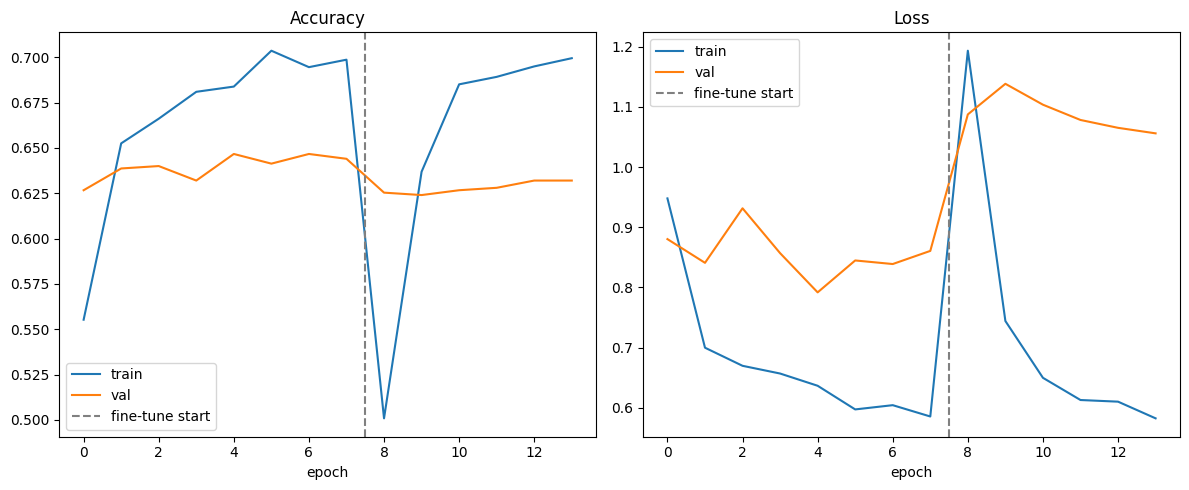

In [17]:
def plot_training_curves(h1, h2):
    acc = h1.history["accuracy"] + h2.history["accuracy"]
    val_acc = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    loss = h1.history["loss"] + h2.history["loss"]
    val_loss = h1.history["val_loss"] + h2.history["val_loss"]
    boundary = len(h1.history["accuracy"])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(acc, label="train")
    axes[0].plot(val_acc, label="val")
    axes[0].axvline(boundary - 0.5, color="gray", linestyle="--", label="fine-tune start")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(loss, label="train")
    axes[1].plot(val_loss, label="val")
    axes[1].axvline(boundary - 0.5, color="gray", linestyle="--", label="fine-tune start")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("epoch")
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(MODEL_DIR / "training_curves.png")
    plt.show()


plot_training_curves(history1, history2)

## 6. Final comparison and model selection\n\nAll four models — Random Forest, XGBoost, SVM, and the MobileNetV2 CNN — are evaluated on the same held-out test split. The most accurate one is kept as the final model for the Student Focus Monitor.

 1/12 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step

 2/12 ━━━━━━━━━━━━━━━━━━━━ 4s 410ms/step

 3/12 ━━━━━━━━━━━━━━━━━━━━ 3s 408ms/step

 4/12 ━━━━━━━━━━━━━━━━━━━━ 3s 412ms/step

 5/12 ━━━━━━━━━━━━━━━━━━━━ 2s 411ms/step

...

10/12 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step

11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 491ms/step


,model,test_accuracy,test_macro_f1
0,SVM,0.653959,0.684556
1,XGBoost,0.651026,0.658173
2,Random Forest,0.633431,0.643578
3,MobileNetV2 CNN,0.628947,0.663246


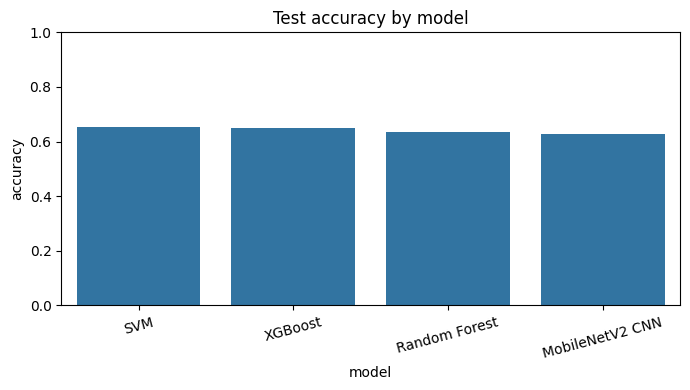


Best model on the held-out test set: SVM (accuracy=0.6540)


In [18]:
def eval_on_test(model, kind):
    if kind == "cnn":
        y_true = np.concatenate([y.numpy() for _, y in test_ds])
        y_pred = np.argmax(model.predict(test_ds), axis=1)
    else:
        y_true = y_test
        y_pred = model.predict(X_test)
    return y_true, y_pred, accuracy_score(y_true, y_pred), f1_score(y_true, y_pred, average="macro")


all_models = {
    "Random Forest": ("classical", rf_model),
    "XGBoost": ("classical", xgb_model),
    "SVM": ("classical", svm_model),
    "MobileNetV2 CNN": ("cnn", cnn_model),
}

comparison_rows = []
predictions = {}
for name, (kind, model) in all_models.items():
    y_true, y_pred, acc, f1 = eval_on_test(model, kind)
    comparison_rows.append({"model": name, "test_accuracy": acc, "test_macro_f1": f1})
    predictions[name] = (y_true, y_pred)

comparison_df = pd.DataFrame(comparison_rows).sort_values("test_accuracy", ascending=False).reset_index(drop=True)
display(comparison_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=comparison_df, x="model", y="test_accuracy")
plt.ylim(0, 1)
plt.title("Test accuracy by model")
plt.ylabel("accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(MODEL_DIR / "model_comparison.png")
plt.show()

best_model_name = comparison_df.iloc[0]["model"]
print(f"\nBest model on the held-out test set: {best_model_name} (accuracy={comparison_df.iloc[0]['test_accuracy']:.4f})")

=== Test-set classification report: SVM ===
              precision    recall  f1-score   support

     Focused      0.716     0.635     0.673       115
     Fatigue      1.000     1.000     1.000        56
     Anxiety      0.782     0.406     0.534       106
     Boredom      0.398     0.797     0.531        64

    accuracy                          0.654       341
   macro avg      0.724     0.709     0.685       341
weighted avg      0.723     0.654     0.657       341



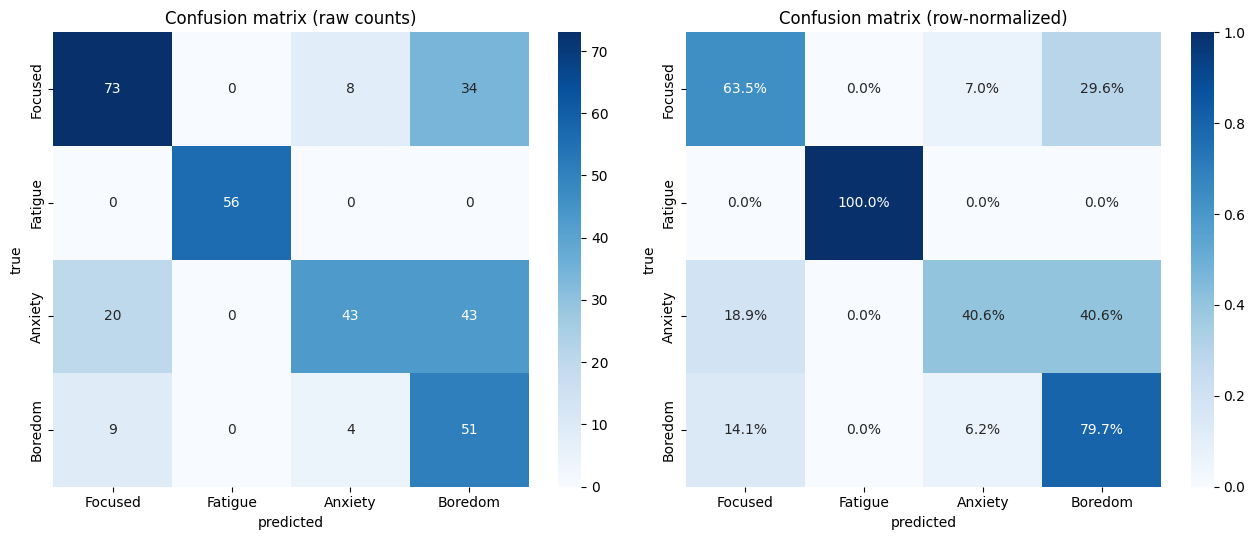

In [19]:
y_true_best, y_pred_best = predictions[best_model_name]

report_text = classification_report(y_true_best, y_pred_best, target_names=CLASSES, digits=3)
print(f"=== Test-set classification report: {best_model_name} ===")
print(report_text)

cm = confusion_matrix(y_true_best, y_pred_best, labels=np.arange(len(CLASSES)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title("Confusion matrix (raw counts)")
axes[0].set_xlabel("predicted")
axes[0].set_ylabel("true")

sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title("Confusion matrix (row-normalized)")
axes[1].set_xlabel("predicted")
axes[1].set_ylabel("true")

fig.tight_layout()
fig.savefig(MODEL_DIR / "confusion_matrix.png")
plt.show()

report_dict = classification_report(y_true_best, y_pred_best, target_names=CLASSES, digits=3, output_dict=True)
with open(MODEL_DIR / "test_classification_report.json", "w") as f:
    json.dump(report_dict, f, indent=2)
with open(MODEL_DIR / "test_classification_report.txt", "w") as f:
    f.write(report_text)

In [20]:
results_summary = {
    "classes": CLASSES,
    "comparison": comparison_df.to_dict(orient="records"),
    "best_model": best_model_name,
    "boredom_threshold": BOREDOM_THRESHOLD,
    "feature_columns": FEATURE_COLUMNS,
}

if best_model_name == "MobileNetV2 CNN":
    cnn_model.save(MODEL_DIR / "focus_mobilenetv2.keras")
    print(f"Saved CNN model to {MODEL_DIR / 'focus_mobilenetv2.keras'}")
else:
    best_model_obj = all_models[best_model_name][1]
    joblib.dump(best_model_obj, MODEL_DIR / "focus_classical_model.joblib")
    joblib.dump(scaler, MODEL_DIR / "feature_scaler.joblib")
    print(f"Saved {best_model_name} model to {MODEL_DIR / 'focus_classical_model.joblib'}")

with open(MODEL_DIR / "results_summary.json", "w") as f:
    json.dump(results_summary, f, indent=2)
print(f"Saved results summary to {MODEL_DIR / 'results_summary.json'}")

Saved SVM model to c:\Users\CNN COMPUTERS\OneDrive\Documents\Research\Smart-Uni-Guide\backend\trained-models\focus\focus_classical_model.joblib
Saved results summary to c:\Users\CNN COMPUTERS\OneDrive\Documents\Research\Smart-Uni-Guide\backend\trained-models\focus\results_summary.json


## 7. Cross-domain regression check

This is the test that originally caught the DAiSEE-domain shortcut: run the winning model on DAiSEE clips it never saw during training (excluded by clip id, not just a random sample), split into clips truly labeled Boredom>=2 and clips truly labeled Boredom==0, and check that the *not-bored* clips are no longer predicted as Boredom almost unconditionally. This goes through the exact same crop -> feature/pixel -> predict path the backend's `inference.py` uses, not the cached training features, so it's a genuine end-to-end check.

In [21]:
N_HELDOUT_PER_GROUP = 25

used_daisee_stems = {
    p.stem.replace("DAiSEE_", "", 1)
    for split in SPLITS
    for cls in CLASSES
    for p in list_images(UNIFIED_ROOT / split / cls)
    if p.name.startswith("DAiSEE_")
}
print(f"{len(used_daisee_stems)} DAiSEE clip stems already used in the unified dataset (excluded below)")

# A fresh landmarker with blendshapes + transformation matrix enabled --
# `_daisee_landmarker` from section 1.2 was only ever used for crop bounding
# boxes and was built without those outputs, so it can't be reused here.
_regression_landmarker = vision.FaceLandmarker.create_from_options(
    vision.FaceLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=str(LANDMARKER_MODEL_PATH)),
        output_face_blendshapes=True,
        output_facial_transformation_matrixes=True,
        num_faces=1,
        running_mode=vision.RunningMode.IMAGE,
    )
)


def predict_single_frame(frame_bgr, landmarker):
    """Mirrors backend/app/services/focus/inference.py's predict_from_frame:
    crop -> features (classical) or pixels (CNN) -> predict. Used here so
    this regression check exercises the real serving path, not the cached
    training features."""
    face = crop_face(frame_bgr, landmarker)
    if face is None:
        return None
    if best_model_name == "MobileNetV2 CNN":
        img = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
        img = tf.keras.applications.mobilenet_v2.preprocess_input(img.astype(np.float32))
        probs = cnn_model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
    else:
        feats = extract_features(landmarker, face)
        if feats is None:
            return None
        vec = scaler.transform(np.array([[feats[c] for c in FEATURE_COLUMNS]]))
        probs = all_models[best_model_name][1].predict_proba(vec)[0]
    return CLASSES[int(np.argmax(probs))]


def heldout_clip_frames(labels_csv, mask_fn, n, exclude_stems, video_dir):
    df = _load_daisee_labels(labels_csv)
    candidates = df[mask_fn(df)]["ClipID"].tolist()
    candidates = [c for c in candidates if Path(c).stem not in exclude_stems]
    rng = random.Random(RANDOM_SEED)
    rng.shuffle(candidates)
    clip_index = index_clip_files(video_dir)

    frames = []
    for clip_id in candidates:
        if len(frames) >= n:
            break
        video_path = clip_index.get(clip_id)
        if video_path is None:
            continue
        cap = cv2.VideoCapture(str(video_path))
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_count // 2)
        ok, frame = cap.read()
        cap.release()
        if ok:
            frames.append(frame)
    return frames


def report_group(name, frames, preds, expected_class):
    hit_rate = np.mean([p == expected_class for p in preds if p is not None])
    breakdown = {c: preds.count(c) for c in CLASSES}
    print(f"{name}, n={len(frames)}:")
    print(f"  predicted {expected_class}: {hit_rate:.1%}")
    print(f"  full breakdown: {breakdown}")
    return hit_rate


bored_frames = heldout_clip_frames(
    DAISEE_ROOT / "Labels" / "TrainLabels.csv", lambda df: df["Boredom"] >= BOREDOM_THRESHOLD,
    N_HELDOUT_PER_GROUP, used_daisee_stems, DAISEE_ROOT / "DataSet" / "Train",
)
not_bored_frames = heldout_clip_frames(
    DAISEE_ROOT / "Labels" / "TrainLabels.csv", lambda df: df["Boredom"] == 0,
    N_HELDOUT_PER_GROUP, used_daisee_stems, DAISEE_ROOT / "DataSet" / "Train",
)
frustrated_frames = heldout_clip_frames(
    DAISEE_ROOT / "Labels" / "TrainLabels.csv", lambda df: df["Frustration"] >= ANXIETY_FRUSTRATION_THRESHOLD,
    N_HELDOUT_PER_GROUP, used_daisee_stems, DAISEE_ROOT / "DataSet" / "Train",
)

bored_preds = [predict_single_frame(f, _regression_landmarker) for f in bored_frames]
not_bored_preds = [predict_single_frame(f, _regression_landmarker) for f in not_bored_frames]
frustrated_preds = [predict_single_frame(f, _regression_landmarker) for f in frustrated_frames]

bored_acc = report_group("Held-out truly-bored clips (Boredom>=2)", bored_frames, bored_preds, "Boredom")
print()
not_bored_fpr = report_group("Held-out truly-NOT-bored clips (Boredom==0)", not_bored_frames, not_bored_preds, "Boredom")
print()
frustrated_acc = report_group("Held-out frustrated clips (Frustration>=2, Anxiety proxy)", frustrated_frames, frustrated_preds, "Anxiety")

print()
if not_bored_fpr > 0.5:
    print("STILL SHOWING THE DOMAIN SHORTCUT: most not-bored DAiSEE clips are still predicted Boredom.")
else:
    print("Fix looks effective: not-bored DAiSEE clips are no longer predicted Boredom by default.")

1532 DAiSEE clip stems already used in the unified dataset (excluded below)


Held-out truly-bored clips (Boredom>=2), n=25:
  predicted Boredom: 48.0%
  full breakdown: {'Focused': 12, 'Fatigue': 0, 'Anxiety': 1, 'Boredom': 12}

Held-out truly-NOT-bored clips (Boredom==0), n=25:
  predicted Boredom: 36.0%
  full breakdown: {'Focused': 15, 'Fatigue': 0, 'Anxiety': 1, 'Boredom': 9}

Held-out frustrated clips (Frustration>=2, Anxiety proxy), n=0:
  predicted Anxiety: nan%
  full breakdown: {'Focused': 0, 'Fatigue': 0, 'Anxiety': 0, 'Boredom': 0}

Fix looks effective: not-bored DAiSEE clips are no longer predicted Boredom by default.


## Conclusion

The saved model plus `results_summary.json` in `trained-models/focus/` are what the real-time focus-monitoring service should load. Because that service computes the exact same MediaPipe eye/face/head features once a second, either the winning classical model (`focus_classical_model.joblib` + `feature_scaler.joblib`) or the CNN (`focus_mobilenetv2.keras`, run directly on the cropped webcam frame) can be plugged in behind the gamification engine described in the project spec -- whichever this notebook found to be the most accurate on held-out test data.

The section 7 regression check is the one that matters most before trusting predictions on a real webcam: it directly measures whether the model still relies on "this looks like a DAiSEE frame" instead of genuine facial cues, for both Boredom and (now) Anxiety. Three of the four classes -- Focused, Anxiety, Boredom -- now have real DAiSEE-domain (webcam video) representation; **Fatigue does not**, since DAiSEE has no drowsiness/yawning label to proxy from. If the regression check still shows a meaningfully elevated false-positive rate, or if Fatigue in particular seems to fire (or fail to fire) based on image quality rather than content, the remaining fix is the same one flagged in round 1: source or capture genuine webcam-quality Fatigue examples (real video, not a curated dataset) so all four classes -- not three -- share one camera domain.